# **Machine Learning _Vademecum_** - Diciotti

## **ROC Curve**
What we learned, for this topic, was how to create a ROC curve for a given dataset. 
1. The first step is always **defining the dataset**, but in most of the cases this is already done and ready to use. It is important, though, to understand the dataset: the number of samples and features we are dealing with, and most importantly what we want to do with it. 

In [155]:
import pandas as pd

data_ideal = {
    'Subject': [f'Subject {i+1}' for i in range(10)],
    'True Label': ['p', 'p', 'p', 'p', 'p', 'p', 'n', 'n', 'n', 'n'],
    'Model Score': [0.99999, 0.99999, 0.99993, 0.99986, 0.99964, 0.99955, 0.68139, 0.50961, 0.48880, 0.44951]
}

data_real = {
    'Subject': [f'Subject {i+1}' for i in range(20)],
    'True Label': ['p', 'p', 'n', 'p', 'p', 'p', 'n', 'n', 'p', 'n', 'p', 'n', 'p', 'n', 'n', 'n', 'p', 'n', 'p', 'n'],
    'Model Score': [0.9, 0.8, 0.7, 0.6, 0.55, 0.54, 0.53, 0.52, 0.51, 0.505, 0.4, 0.39, 0.38, 0.37, 0.36, 0.35, 0.34, 0.33, 0.30, 0.1]
}

data = data_real

df = pd.DataFrame(data)
df

,Subject,True Label,Model Score
0,Subject 1,p,0.900
1,Subject 2,p,0.800
2,Subject 3,n,0.700
3,Subject 4,p,0.600
4,Subject 5,p,0.550
5,Subject 6,p,0.540
6,Subject 7,n,0.530
7,Subject 8,n,0.520
8,Subject 9,p,0.510
9,Subject 10,n,0.505


2. - The second step is to convert, if needed, the positive and negative labels into binary values. This is done using a for cycle.
   - To **create the ROC curve** it is important to test all the thresholds we have in our data, so we sort them out from the highest to the lower.
   - The starting point is a very high threshold that does not allow any data to "pass"; so we create an array of all zeros. At this point we have to use the confusion matrix, a function that we import from sklearn.metrics, to calculate how many mistakes we make with this very high threshold.
   - Lastly we use all the other thresholds, repeating the same scheme.

In [156]:
import numpy as np
from sklearn.metrics import confusion_matrix

y_true = []
for label in df['True Label']:
    if label == 'p':
            y_true.append(1)
    else:
        y_true.append(0)

score = df['Model Score']
all_thresholds = np.sort(np.unique(score))[::-1]

y_pred_inf = []
for s in score:
    y_pred_inf.append(0)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_inf).ravel()
fpr_list = [fp / (fp + tn)]
tpr_list = [tp / (tp + fn)]

for threshold in all_thresholds:
    y_pred = []
    for s in score:
        if s >= threshold:
            y_pred.append(1)
        else:
            y_pred.append(0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr_list.append(tp / (tp + fn))
    fpr_list.append(fp / (fp + tn))

3. We have now to **visualize the ROC curve** we just created, which is the trade-off between the FPR and the TPR. We can also calculate the AUC value.

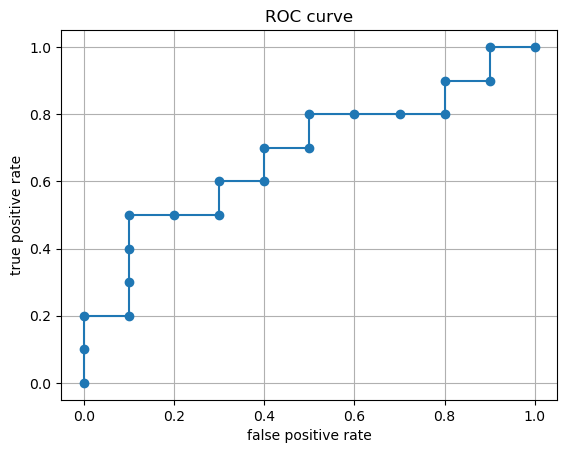

In [157]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc

plt.plot(fpr_list, tpr_list, marker='o')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('ROC curve')
plt.grid(True)

roc_auc = auc(fpr_list, tpr_list)

## **Underfitting and Overfitting**
Underfitting and overfitting are two very important concepts in Machine Learning and to better understand them, interactive plots are very useful. In these plots we can adjust model capacity and noise levels.

1. Firstly, we **create the dataset**; the points create a parabolic shape.

Text(0.5, 1.0, 'true underlyling function of the data')

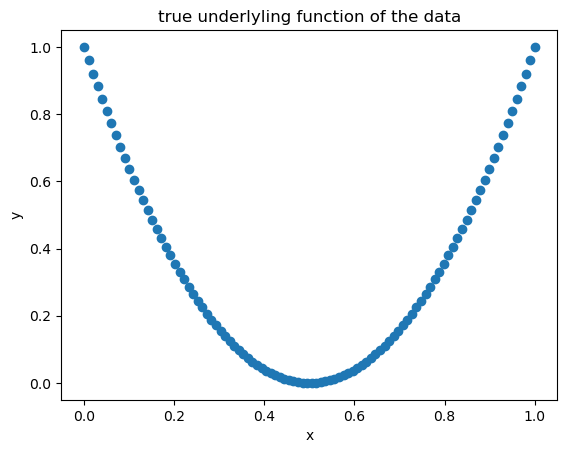

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples).reshape(-1, 1)
y_true = 4 * (X.ravel() - 0.5) ** 2

plt.scatter(X,y_true)
plt.xlabel('x')
plt.ylabel('y')
plt.title('true underlying function of the data')

2. We create a function which takes as input the degree of the polynomial model and the standard deviation of the noise. In the function we perform the following tasks:
    * Adding noise to the data.
    * Splitting the data randomly into train and test subsets.
    * Performing a polynomial regression. In sklearn there is no PolynomialRegression model, thus, we have to perform it in two different steps:
        - We use **PolynomialFeatures** which takes a column of X and it creates new columns with its powers (2/3/... accordingly to the degree).
        - We use **LinearRegression** to fit the model and predict the values.
    * Plotting of the true function (without noise), data with noise and the model created by the polynomial regression. We make the plot interactive in order to change the degree of the polynomial and the standard deviation of the noise. 


In [159]:
from ipywidgets import interact
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_polynomial_fit(degree=1, noise_std=0.1):
    y = y_true + noise_std * np.random.randn(n_samples)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    poly = PolynomialFeatures(degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    X_plot = np.linspace(0, 1, 200).reshape(-1, 1) 
    y_plot = model.predict(poly.transform(X_plot))
    plt.figure(figsize=(7, 5))
    plt.scatter(X_train, y_train, color='blue', label='Train data', s=20)
    plt.plot(X_plot, y_plot, color='red', label=f'Degree {degree}')
    plt.plot(X, y_true, '--', color='green', label='True function')
    plt.title(f"noise std = {noise_std}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_polynomial_fit, degree=(1, 15), noise_std=(0.0, 1.0, 0.05))

interactive(children=(IntSlider(value=1, description='degree', max=15, min=1), FloatSlider(value=0.1, descript…

<function __main__.plot_polynomial_fit(degree=1, noise_std=0.1)>

3. Lastly, we calculate the **MSE both for the training and test set**. This way we can understand that:
    - Low-degree models may underfit (high error on both sets).
    - High-degree models may overfit (low training error but high test error).
    - Higher noise levels make overfitting occur earlier.

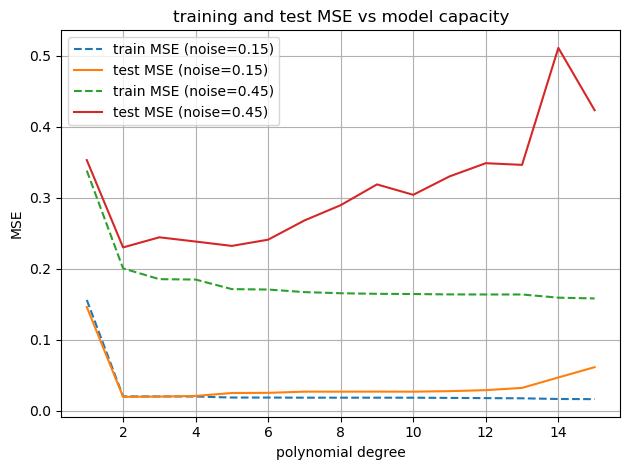

In [160]:
np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples).reshape(-1, 1)
y_true = 4 * (X.ravel() - 0.5) ** 2

degrees = range(1, 16)
noise_levels = [0.15, 0.45]

for noise_std in noise_levels:
    y = y_true + noise_std * np.random.randn(n_samples)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    train_mse = []
    test_mse = []

    for degree in degrees:
        poly = PolynomialFeatures(degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = LinearRegression()
        model.fit(X_train_poly, y_train)

        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)

        train_mse.append(mean_squared_error(y_train, y_train_pred))
        test_mse.append(mean_squared_error(y_test, y_test_pred))

    plt.plot(degrees, train_mse, linestyle='--', label=f'train MSE (noise={noise_std})')
    plt.plot(degrees, test_mse, label=f'test MSE (noise={noise_std})')

plt.xlabel('polynomial degree')
plt.ylabel('MSE')
plt.title('training and test MSE vs model capacity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **Weight Decay**
In Machine Learning, Weight Decay is a regularization technique that consists in adding a penalty to the cost function to express a preference for solutions with smaller L2-norm of the weights; this, consequently, improves generalization. The flow of the tasks to complete is very similar to one of the previous topic. 
1. Firstly, we **create the dataset**; the points create a parabolic shape.

Text(0.5, 1.0, 'true underlyling function of the data')

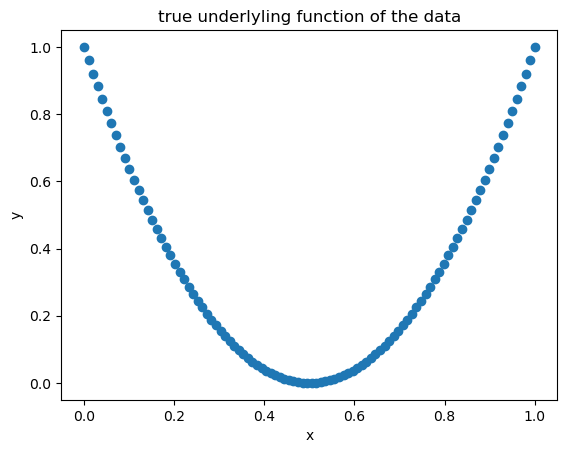

In [161]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples).reshape(-1, 1)
y_true = 4 * (X.ravel() - 0.5) ** 2

plt.scatter(X,y_true)
plt.xlabel('x')
plt.ylabel('y')
plt.title('true underlyling function of the data')

2. We create a function that takes as input the lambda hyperparameter 
and the standard deviation of the noise.
    * Add noise to the data.
    * Split the data randomly into train and test subsets.
    * The polynomial degree is kept fixed at a high value to deliberately start in an overfitting regime, so that the effect of lambda is visible.
    * Perform a polynomial regression. In sklearn there is no PolynomialRegression model, thus, we have to perform it in two different steps:
        - We use **PolynomialFeatures** which takes a column of X and it creates new columns with its powers (2/3/... accordingly to the degree).
        - We use **RidgeRegression** to fit the model and predict the values. Ridge method performs exactly the weight decay we are aiming to study.
    * Plotting of the true function (without noise), data with noise and the model created by the Weight Decay. We make the plot interactive in order to change the hyperparameter value and the standard deviation of the noise.

In [162]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

fixed_degree = 25

def plot_weight_decay(lambda_value=0.0, noise_std=0.1):
    y = y_true + noise_std * np.random.randn(n_samples)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    poly = PolynomialFeatures(degree=fixed_degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    model = Ridge(alpha=lambda_value)
    model.fit(X_train_poly, y_train)
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
    y_plot = model.predict(poly.transform(X_plot))

    plt.figure(figsize=(7, 5))
    plt.scatter(X_train, y_train, color='blue', label='train data', s=20)
    plt.plot(X_plot, y_plot, color='red', label=f'degree {fixed_degree}')
    plt.plot(X, y_true, '--', color='green', label='true function')
    plt.title(f"noise std = {noise_std} | lambda = {lambda_value}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

interact(plot_weight_decay, lambda_value=(0.0, 0.2, 0.05), noise_std=(0.0, 1.0, 0.05))

interactive(children=(FloatSlider(value=0.0, description='lambda_value', max=0.2, step=0.05), FloatSlider(valu…

<function __main__.plot_weight_decay(lambda_value=0.0, noise_std=0.1)>

3. Lastly, we create a plot showing how the training and test **Mean Squared Error (MSE) change as we increase the strength of weight decay** (lambda) in a high-degree polynomial model (degree = 25). We compare two scenarios: low noise (noise_std = 0.15) - high noise (noise_std = 0.25).
    * When lambda = 0 (no weight decay), the model tends to overfit, especially with noisy data.
    * Increasing lambda helps reduce overfitting by penalizing large weights, leading to better generalization.
    * If lambda becomes too large, the model may underfit and the error increases again.

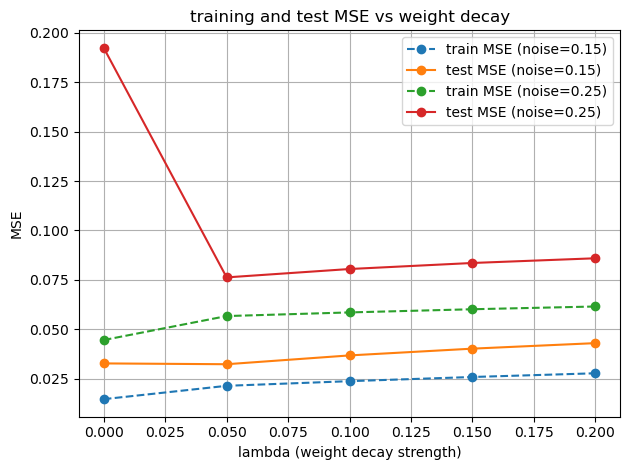

In [163]:
from sklearn.metrics import mean_squared_error

np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples).reshape(-1, 1)
y_true = 4 * (X.ravel() - 0.5) ** 2

fixed_degree = 25
noise_levels = [0.15, 0.25]
lambdas = np.arange(0.0, 0.25, 0.05)

for noise_std in noise_levels:
    y = y_true + noise_std * np.random.randn(n_samples)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    train_mse = []
    test_mse = []

    for lambda_value in lambdas:
        poly = PolynomialFeatures(fixed_degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        model = Ridge(alpha=lambda_value)
        model.fit(X_train_poly, y_train)

        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)

        train_mse.append(mean_squared_error(y_train, y_train_pred))
        test_mse.append(mean_squared_error(y_test, y_test_pred))

    plt.plot(lambdas, train_mse, linestyle='--', marker='o', label=f'train MSE (noise={noise_std})')
    plt.plot(lambdas, test_mse, marker='o', label=f'test MSE (noise={noise_std})')

plt.xlabel('lambda (weight decay strength)')
plt.ylabel('MSE')
plt.title('training and test MSE vs weight decay')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## **Age Prediction Example**

### Data Preparation and **EDA (Exploratory Data Analysis)**
We are now trying to explore the regression and classification task, using a specific dataset. In this part we are going to prepare the data and explore them to have a better understanding of what we are dealing with.
* Firstly, we import the dataset as DataFrame and print it. Looking at it we can understand that it's a set of cerebral MRI-derived features performed on subjects; these are the values that we will use to perform regression and classification tasks. For each patient we are given also age and sex.
* We check the shape of the dataset.
* We remove the missing data.

In [164]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('https://raw.githubusercontent.com/sdiciotti/Age-Prediction-Demo/main/NKI2_data.xlsx')
print(df)
features = list(df.columns)
print(features)

print("dataframe shape before NaN removal:", df.shape)

df.dropna(axis=0, how='any', inplace=True)
print("dataframe shape after NaN removal:", df.shape)

    Age Sex  cortex_CT  lh_cortex_CT  rh_cortex_CT  lh_frontalGM_CT  \
0    13   F   2.563765       2.53793       2.58960            2.604   
1    13   M   2.816775       2.80403       2.82952            2.870   
2    16   F   2.590785       2.60300       2.57857            2.659   
3    17   M   2.618340       2.62847       2.60821            2.780   
4    17   M   2.737575       2.77298       2.70217            2.866   
..  ...  ..        ...           ...           ...              ...   
68   14   F   2.785335       2.80093       2.76974            2.956   
69   16   M   2.645850       2.62908       2.66262            2.793   
70   12   F   2.731690       2.73606       2.72732            2.854   
71   10   F   2.674965       2.67007       2.67986            2.749   
72   11   M   2.733215       2.74924       2.71719            2.846   

    lh_occipitalGM_CT  lh_temporalGM_CT  lh_parietalGM_CT  rh_frontalGM_CT  \
0               2.084             2.694             2.432            

### **Classification** with **CV** and **nested-CV**
1. When performing a classification task starting from a continuous variable (age), we need to discretize it into categories, this means dividing the dataset into two subsections by converting the continuous value into a discrete one. To do this we create a function that **categorizes the age** and then apply it to the dataset.

In [165]:
def categorize_age(age):
    if age <= 11:
        return 0
    else:
        return 1
    
df['Age category'] = df['Age'].apply(categorize_age)

2. **Logistic Regression using a CV scheme**
    * Firstly, we select data we are interested to: the age category column, which contains the true values, and all the cerebral measurments.
    * Then, we create the LogisticRegression and KFold objects in order to use them in the cross_validate function. This function gives us a score for the model; we can select different parameters to evaluate, in this case we looked at the AUC value. 

In [166]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=['Age', 'Sex', 'Age category'])
y = df['Age category']

lr = LogisticRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
score = cross_validate(lr, X=X, y=y, cv=kf, return_train_score=True, scoring='roc_auc', )
print('AUC score for the train set is:', np.mean(score['train_score']))
print('AUC score for the test set is:', np.mean(score['test_score']))

AUC score for the train set is: 0.9721221959044539
AUC score for the test set is: 0.9648148148148149


3. **Logistic Regression with hyperparameters and using nested CV scheme**
    * In this case, since we are considering a nested CV scheme, we have to set the number of folds both for the outer and inner loop. This way we create two different objects with KFold. We create also the LogisticRegression object.
    * The difference with the previous task is that, here, we have also to define the best hyperparameter and this is done using the GridSearchCV method; this method needs the estimator, a set of hyperparameter values (more precisely a dictionary), the inner KFold object, the scoring we want to look at and the refit parameter set on the same value as the scoring; the refit parameter allows to refit an estimator using the best parameter found. 

In [167]:
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression

outer_n_folds = 5
inner_n_folds = 5
outer_kf = KFold(n_splits=outer_n_folds, shuffle=True, random_state=42)
inner_kf = KFold(n_splits=inner_n_folds, shuffle=True, random_state=42)
lr = LogisticRegression(max_iter=1000)

C = [0.1, 1, 10]
p_grid = [{'C': C}]
lr_gs = GridSearchCV(estimator=lr, param_grid=p_grid, refit='roc_auc', scoring='roc_auc', cv=inner_kf)
score = cross_validate(lr_gs, X=X, y=y, scoring='roc_auc', cv=outer_kf, return_train_score=True)
print('AUC score for the train set is:', np.mean(score['train_score']))
print('AUC score for the test set is:', np.mean(score['test_score']))


AUC score for the train set is: 0.971619828349667
AUC score for the test set is: 0.9685185185185186


### **Classification** with **holdout** and **nested holdout**
Since the task is very similar to the previous one the first step is the same. We start from the second:
1. **Logistic Regression using a holdout scheme**
    * In the holdout case, we do not have a method that does the splitting automatically, thus, we have to use the function train_test_split, setting the parameter test_size to a precise value; this is done because this way we can decide the proportion of the test set to the train set. 
    * After doing this, we create the LogisticRegression object and use the fit and predict_proba functions; we use predict_proba and not just predict because the roc_auc_score function needs a continous probability, and not the predicted classes. 
    * Lastly, we use the roc_auc_score to get the AUC value for both training and test set. 

In [168]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

test_size = 0.1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_proba_test = lr.predict_proba(X_test)[:, 1]
y_pred_proba_train = lr.predict_proba(X_train)[:, 1]

auc_train = roc_auc_score(y_train, y_pred_proba_train)
auc_test = roc_auc_score(y_test, y_pred_proba_test)
print("average AUC training set:", auc_train)
print("average AUC test set:", auc_test)


average AUC training set: 0.968627450980392
average AUC test set: 1.0


2. **Logistic Regression with hyperparameter and using nested holdout scheme**
    * Firstly, we divide the whole dataset into the development set and the test set. The development set has to be divided again into validation (for hyperparameter tuning) and train set.
    * We set some values for the hyperparameter and in a for loop we test them using the LogisticRegression.fit/predict_proba and the roc_auc_score to evaluate them and fin the best one. 
    * Lastly, we refit the model and calculate the AUC value with the best hyperparameter found. 

In [176]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

test_size = 0.1
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=test_size, random_state=42)

C = [0.1, 1, 10]
AUC = []
for c in C:
    lr = LogisticRegression(C=c)
    lr.fit(X_train, y_train)
    y_pred_proba_val = lr.predict_proba(X_val)[:,1]
    AUC.append(roc_auc_score(y_val, y_pred_proba_val))
bestC_index = np.argmax(AUC)
bestC = C[bestC_index]

lr = LogisticRegression(C=bestC).fit(X_dev, y_dev)
y_pred_proba_test_nho = lr.predict_proba(X_test)[:, 1]
auc_test = roc_auc_score(y_test, y_pred_proba_test_nho)
print("average AUC test set:", auc_test)


average AUC test set: 1.0


### **Regression** with **CV** and **nested CV**
1. **Linear Regression using a CV scheme**
    * Firstly, we create the estimator; apparently, the parameters are set to values which are not further explained, so we take them for granted. However, it is important to understand them:
        - kernel is the most important and can take also the strings 'linear' or 'poly'.
        - C indicates the hyperparameter.
        - epsilon is the tolerance.
        - gamma is related to kernel and it has a meaning only with kernel = 'rbf'/'poly'; 'scale' is the default value. 
    * We also create the KFold object.
    * Eventually, we calculate the score using the cross_validate function with scoring 'neg_mean_absolute_error'. 


In [ ]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.svm import SVR

reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=1, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

score = cross_validate(estimator=reg, X=X, y=y, scoring='neg_mean_absolute_error', cv=kf, return_train_score=True)
print('average MAE for training set:', np.mean(np.abs(score['train_score'])))
print('average MAE for test set:', np.mean(np.abs(score['test_score'])))


average MAE for training set: 0.21580016696787752
average MAE for test set: 0.2499387733707749


2. **Linear Regression with hyperparameter and using nested CV scheme**: the process is very similar to what we did in the classification task with a hyperparameter and a nested Cv scheme. In this case what we change is the estimator, obviously, and the scoring of the cross_validate function which takes the form of 'neg_mean_absolute_error'.

In [ ]:
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from sklearn.svm import SVR

outer_n_folds = 5
inner_n_folds = 5
outer_kf = KFold(n_splits=outer_n_folds, shuffle=True, random_state=42)
inner_kf = KFold(n_splits=inner_n_folds, shuffle=True, random_state=42)
reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=1, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1)
C = [0.1, 1, 10]
p_grid = [{'C': C}]
reg_gs = GridSearchCV(estimator=reg, param_grid=p_grid, refit='neg_mean_absolute_error', scoring='neg_mean_absolute_error', cv=inner_kf)
score = cross_validate(reg_gs, X=X, y=y, scoring='neg_mean_absolute_error', cv=outer_kf, return_train_score=True)
print('average MAE score for the train set is:', np.mean(np.abs(score['train_score'])))
print('average MAE score for the test set is:', np.mean(np.abs(score['test_score'])))

average MAE score for the train set is: 0.138777979431337
average MAE score for the test set is: 0.18095238095238092


## **Regression** with **holdout** and **nested holdout**
1. **Linear Regression using a holdout scheme**
    * Firstly, we use the train_test_split function to divide the dataset into train and test set. 
    * We create the LinearRegression object to fit the data and predict the new ones. 
    * Lastly, we calculate the MAE for the test set.


In [172]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

reg = LinearRegression().fit(X_train, y_train)
y_pred = reg.predict(X_test)

mae = mean_absolute_error(y_true=y_test, y_pred=y_pred)
print('MAE for the test set:', mae)

MAE for the test set: 0.344581875653164


2. **Polynomial Regression using a nested holdout scheme**
    * As we've seen before, in the holdout scheme the first step is always to divide the dataset into subsets using the train_test_split function. In this case we are performing a nested holdout so we have to do this step two times. 
    * The Polynomial Regression method does not exist in sklearn library, thus, we need to use PolynomialFeatures to generate a new matrix consisting of all polynomial combinations of the features with degree less than or equal to the specified degree. The degree is not set so we need to test different values. 
    * On this data we use the LinearRegression and for every degree we calculate the MAE.
    * Out of all the degrees tested we now have to find the best one by looking at the MAE value. 
    * Eventually, we retrain the Polynomial Regression model on the best degree. 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error

X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.1, random_state=42, shuffle=True)

MAE = []
degrees = [1, 2, 3, 4, 5]
for deg in degrees:
    pf = PolynomialFeatures(degree=deg)
    X_train_poly = pf.transform(X_train)
    X_val_poly = pf.transform(X_val)

    reg = LinearRegression().fit(X_train_poly, y_train)
    y_pred = reg.predict(X_val_poly)

    MAE.append(mean_absolute_error(y_val, y_pred))

best_degree_index = np.argmin(MAE)
best_degree = degrees[best_degree_index]

pf = PolynomialFeatures(degree=best_degree)
X_dev_poly = pf.transform(X_dev)
X_test_poly = pf.transform(X_test)
reg = LinearRegression().fit(X_dev_poly, y_dev)
y_pred = reg.predict(X_test_poly)
MAE = mean_absolute_error(y_pred, y_test)
print ("MAE test set:", MAE)

MAE test set: 0.34458187565316045


3. **Support Vector Regression (SVR) with hyperparameter and using a nested holdout validation scheme**
    * We define a set of hyperparameter values to test in a for loop.
    * In the for loop we create the regression object with different hyperparameter values, we train the model and then calculate the mean absolute error for each of them. 
    * We find the optimal value of the MAE among the calculated ones. 
    * We retrain the SVR model to using the best hyperparameter and calculate the final MAE.

In [175]:
from sklearn.svm import SVR

MAE = []
Cs = [0.1, 1, 10]
for c in Cs:
    reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=c, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1).fit(X_train, y_train)
    y_val_pred = reg.predict(X_val)
    MAE_c = mean_absolute_error(y_val, y_val_pred)
    MAE.append(MAE_c)

bestC_index = np.argmin(MAE)
bestC = Cs[bestC_index]

reg = SVR(kernel='rbf', degree=3, gamma='scale', coef0=0.0, tol=0.001, C=bestC, epsilon=0.1, shrinking=True, cache_size=200, verbose=0, max_iter=- 1).fit(X_dev, y_dev)
y_test_pred = reg.predict(X_test)
MAE = mean_absolute_error(y_test, y_test_pred)
print ("MAE test set:", MAE)


MAE test set: 0.23779814304387187
